In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

base_dir = r"C:\Users\SS\OneDrive\Desktop\University\Semester 6\pneumonia_project\chest_xray"

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(base_dir + r"\test", transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Test images: {len(test_dataset)}")
print(f"Classes: {test_dataset.classes}")
print("✅ Ready!")

Using: cuda
Test images: 624
Classes: ['NORMAL', 'PNEUMONIA']
✅ Ready!


In [2]:
# ============================================================
# We need to rebuild the SAME architecture as before
# Then load the saved weights (best_cnn_scratch.pth)
# Think of it like: the architecture = empty brain structure
#                   the weights     = all the knowledge learned
# ============================================================

class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Load the saved best model
model_cnn = PneumoniaCNN().to(device)
model_cnn.load_state_dict(torch.load("best_cnn_scratch.pth", map_location=device))
model_cnn.eval()   # switch to evaluation mode

print("✅ CNN model loaded successfully!")
print("🧠 Now running on the 624 test images it has NEVER seen before...")

✅ CNN model loaded successfully!
🧠 Now running on the 624 test images it has NEVER seen before...


C:\Users\SS\AppData\Local\Temp\ipykernel_62540\3742468110.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_cnn.load_state_dict(torch.load("best_cnn_scratch.pth", m

In [3]:
# ============================================================
# We go through ALL 624 test images
# For each image, the model gives 2 scores:
#   score[0] = confidence it's NORMAL
#   score[1] = confidence it's PNEUMONIA
# We pick the higher one as the prediction
# ============================================================

all_labels  = []   # real answers
all_preds   = []   # model's guesses
all_probs   = []   # model's confidence scores (for ROC curve)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn(images)

        probs      = torch.softmax(outputs, dim=1)  # convert scores to probabilities (0-1)
        predicted  = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # probability of PNEUMONIA

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

# Basic accuracy
correct  = (all_labels == all_preds).sum()
accuracy = correct / len(all_labels) * 100
print(f"✅ Predictions done!")
print(f"Test Accuracy: {accuracy:.2f}%  ({correct}/{len(all_labels)} correct)")

✅ Predictions done!
Test Accuracy: 83.49%  (521/624 correct)


In [4]:
# ============================================================
# CLASSIFICATION REPORT — the full doctor's report card
#
# Precision = of all images AI called PNEUMONIA, how many were really PNEUMONIA?
#             (avoids false alarms)
# Recall    = of all real PNEUMONIA images, how many did AI catch?
#             (avoids missing sick patients — THIS IS THE MOST IMPORTANT ONE!)
# F1-Score  = balance between precision and recall
# ============================================================

print("=" * 55)
print("       FULL CLASSIFICATION REPORT — CNN from Scratch")
print("=" * 55)
print(classification_report(all_labels, all_preds,
                             target_names=["NORMAL", "PNEUMONIA"]))

roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("=" * 55)
print("\n💡 In medical AI, Recall for PNEUMONIA is most critical!")
print("   Missing a sick patient is worse than a false alarm.")

       FULL CLASSIFICATION REPORT — CNN from Scratch
              precision    recall  f1-score   support

      NORMAL       0.90      0.63      0.74       234
   PNEUMONIA       0.81      0.96      0.88       390

    accuracy                           0.83       624
   macro avg       0.86      0.79      0.81       624
weighted avg       0.85      0.83      0.83       624

ROC-AUC Score: 0.9140

💡 In medical AI, Recall for PNEUMONIA is most critical!
   Missing a sick patient is worse than a false alarm.



Confusion Matrix Breakdown:
  True  Negative (correctly said NORMAL)    : 147
  False Positive (said PNEUMONIA, was NORMAL): 87  ← false alarm
  False Negative (said NORMAL, was PNEUMONIA): 16  ← DANGEROUS miss
  True  Positive (correctly said PNEUMONIA)  : 374


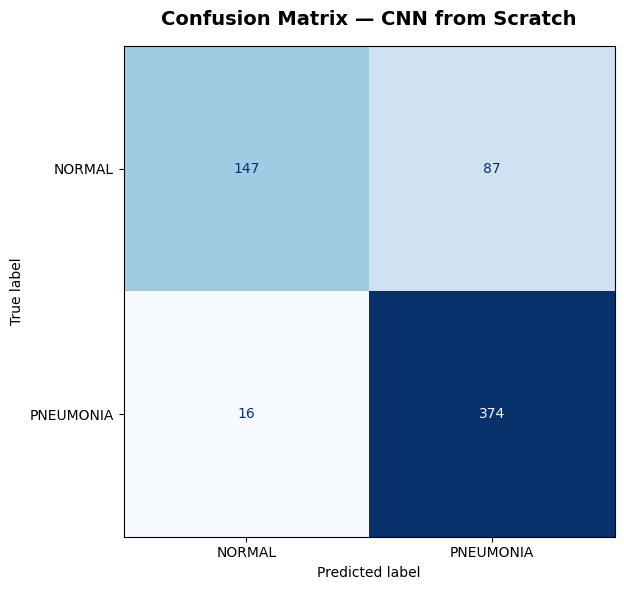

In [5]:
# ============================================================
# CONFUSION MATRIX — shows exactly what the AI got right/wrong
#
#                  Predicted NORMAL | Predicted PNEUMONIA
# Actual NORMAL  |   True Negative  |   False Positive  |
# Actual PNEUM.  |   False Negative |   True Positive   |
#
# False Negative = AI said NORMAL but patient actually had PNEUMONIA
#                 → DANGEROUS in medical context!
# ============================================================

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — CNN from Scratch", fontsize=14, fontweight='bold', pad=15)

# Add annotations explaining each cell
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True  Negative (correctly said NORMAL)    : {tn}")
print(f"  False Positive (said PNEUMONIA, was NORMAL): {fp}  ← false alarm")
print(f"  False Negative (said NORMAL, was PNEUMONIA): {fn}  ← DANGEROUS miss")
print(f"  True  Positive (correctly said PNEUMONIA)  : {tp}")

plt.tight_layout()
plt.savefig("confusion_matrix_cnn.png", dpi=150)
plt.show()

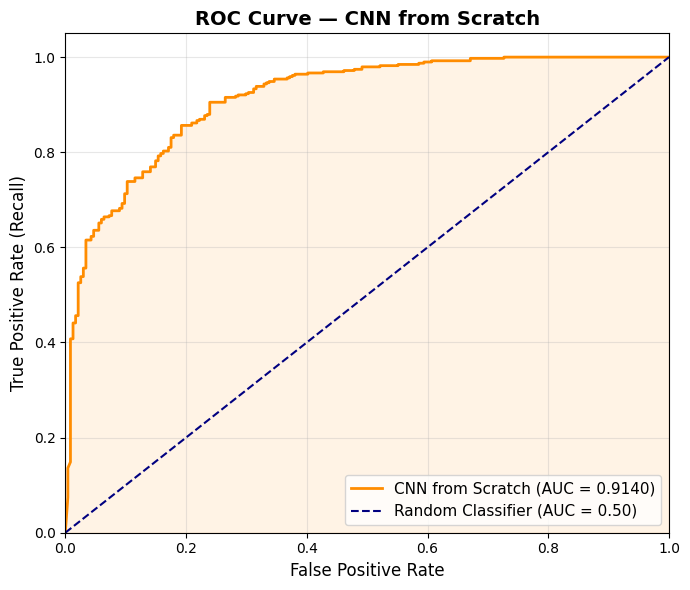


✅ ROC-AUC: 0.9140
AUC > 0.90 = Excellent model! 🎉


In [6]:
# ============================================================
# ROC CURVE — shows how well the model separates sick vs healthy
# AUC (Area Under Curve) closer to 1.0 = perfect model
# AUC = 0.5 = random guessing (useless!)
# ============================================================

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'CNN from Scratch (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — CNN from Scratch', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_cnn.png", dpi=150)
plt.show()

print(f"\n✅ ROC-AUC: {roc_auc:.4f}")
print("AUC > 0.90 = Excellent model! 🎉" if roc_auc > 0.90 else "AUC > 0.80 = Good model!")